# Eksperimen Machine Learning - Heart Failure Prediction


# **1. Perkenalan Dataset**


Dataset ini merupakan gabungan dari 5 dataset jantung yang berbeda (Cleveland, Hungarian, Switzerland, Long Beach VA, dan Statlog), menghasilkan **918 baris** dengan **12 kolom** (11 fitur + 1 target).

### Deskripsi Fitur:
| Fitur | Tipe | Deskripsi |
|-------|------|----------|
| Age | Numerik | Usia pasien (tahun) |
| Sex | Kategorikal | Jenis kelamin (M/F) |
| ChestPainType | Kategorikal | Tipe nyeri dada (ATA/NAP/ASY/TA) |
| RestingBP | Numerik | Tekanan darah istirahat (mm Hg) |
| Cholesterol | Numerik | Kolesterol serum (mm/dl) |
| FastingBS | Biner | Gula darah puasa > 120 mg/dl (1=Ya, 0=Tidak) |
| RestingECG | Kategorikal | Hasil ECG istirahat (Normal/ST/LVH) |
| MaxHR | Numerik | Detak jantung maksimum |
| ExerciseAngina | Kategorikal | Angina akibat olahraga (Y/N) |
| Oldpeak | Numerik | Nilai ST depression |
| ST_Slope | Kategorikal | Kemiringan segmen ST (Up/Flat/Down) |


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Tampilan
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
df = pd.read_csv('heart.csv')

print('✅ Dataset berhasil dimuat!')
print(f'📊 Jumlah baris  : {df.shape[0]}')
print(f'📊 Jumlah kolom : {df.shape[1]}')
print(f'📊 Ukuran dataset : {df.shape}')

✅ Dataset berhasil dimuat!
📊 Jumlah baris  : 918
📊 Jumlah kolom : 12
📊 Ukuran dataset : (918, 12)


In [ ]:
print('=== 5 Baris Pertama Dataset ===')
df.head()

=== 5 Baris Pertama Dataset ===


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
print('=== Informasi Dataset ===')
df.info()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
print('=== Statistik Deskriptif ===')
df.describe()

=== Statistik Deskriptif ===


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

### 4.1 Cek Missing Values & Duplikasi

In [ ]:
# Missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

# Duplikasi
print(f'\n=== Data Duplikat ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

=== Missing Values ===
                Missing Count  Missing %
Age                         0        0.0
Sex                         0        0.0
ChestPainType               0        0.0
RestingBP                   0        0.0
Cholesterol                 0        0.0
FastingBS                   0        0.0
RestingECG                  0        0.0
MaxHR                       0        0.0
ExerciseAngina              0        0.0
Oldpeak                     0        0.0
ST_Slope                    0        0.0
HeartDisease                0        0.0

Total missing values: 0

=== Data Duplikat ===
Jumlah baris duplikat: 0


### 4.2 Distribusi Target Variable

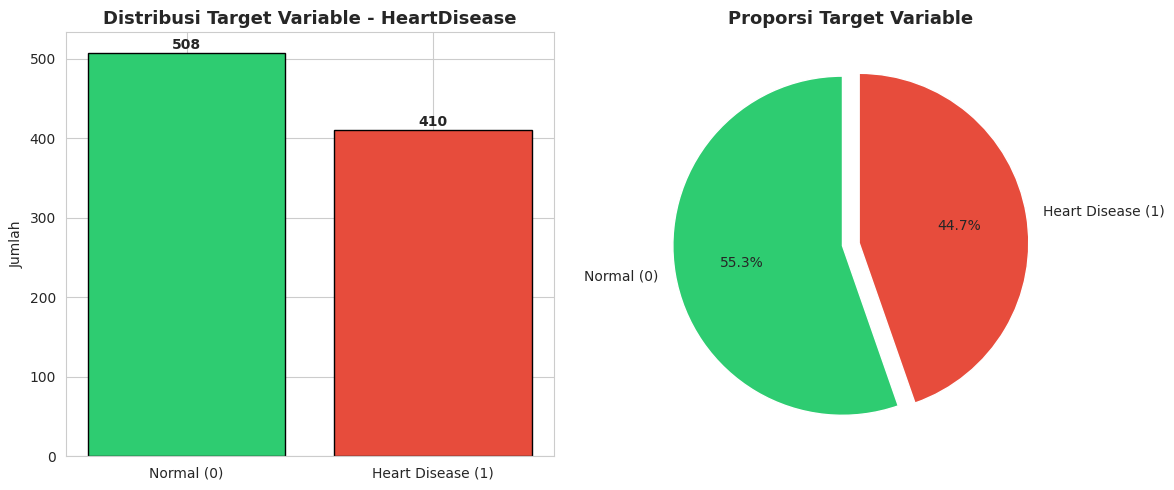


Normal    : 410 (44.7%)
Heart Disease: 508 (55.3%)


In [ ]:
# Distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
target_counts = df['HeartDisease'].value_counts()
axes[0].bar(['Normal (0)', 'Heart Disease (1)'], target_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribusi Target Variable - HeartDisease', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Normal (0)', 'Heart Disease (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Proporsi Target Variable', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nNormal    : {target_counts[0]} ({target_counts[0]/len(df)*100:.1f}%)')
print(f'Heart Disease: {target_counts[1]} ({target_counts[1]/len(df)*100:.1f}%)')

### 4.3 Distribusi Fitur Numerik

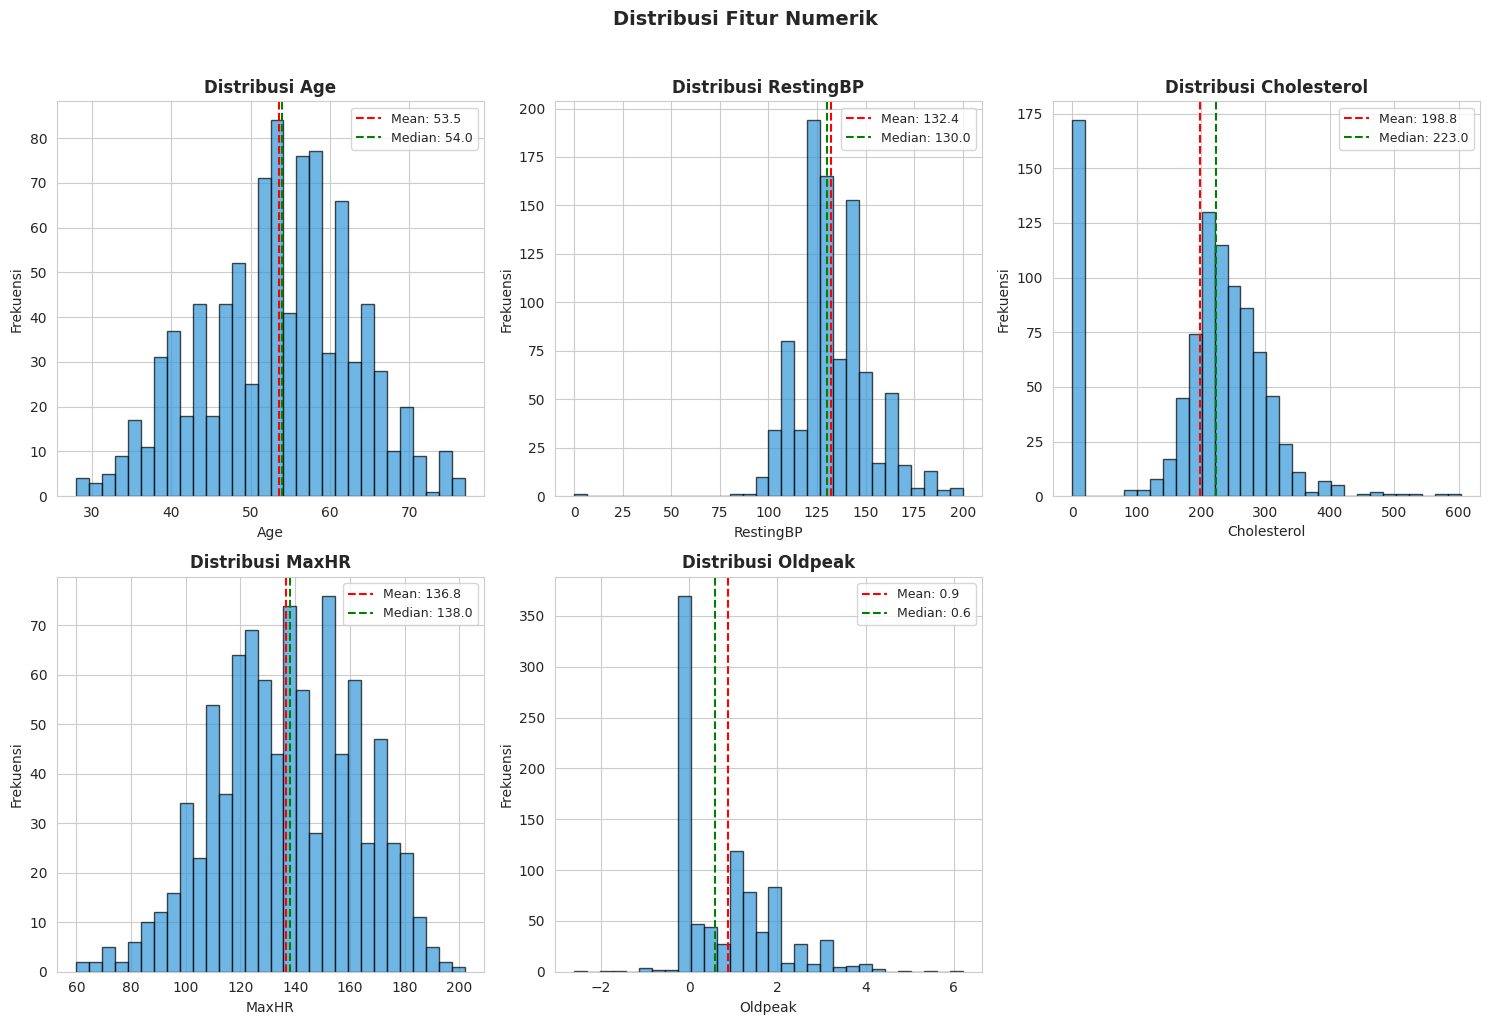

In [ ]:
# Fitur numerik
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.1f}')
    axes[i].legend(fontsize=9)

axes[5].set_visible(False)
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('numerical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Distribusi Fitur Kategorikal

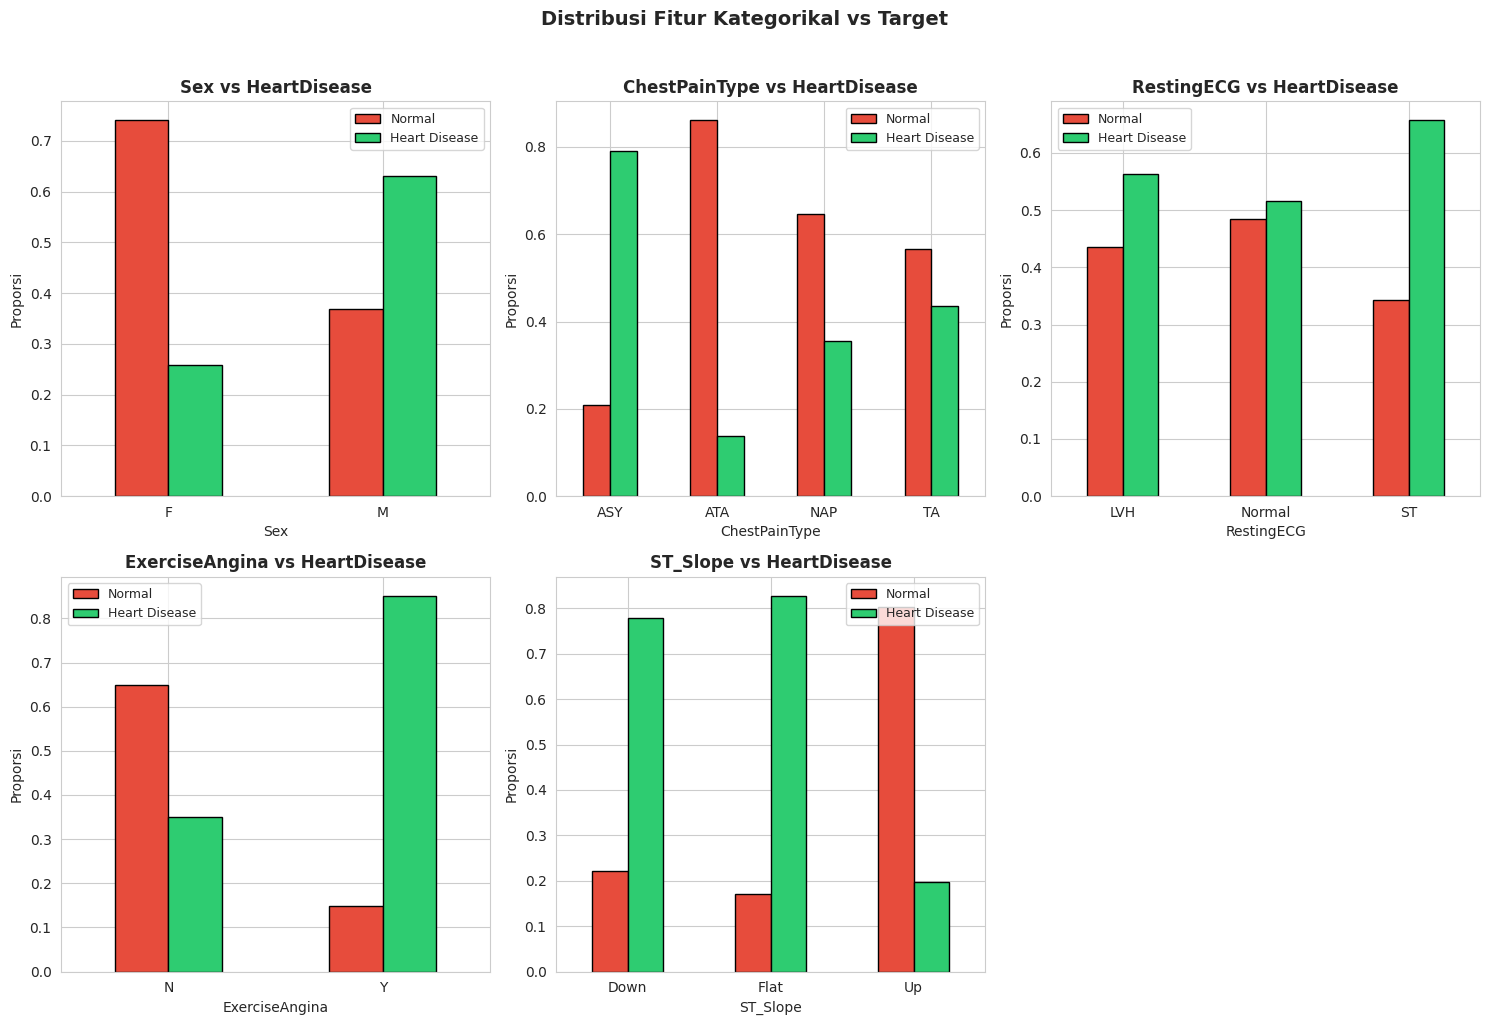

In [ ]:
# Fitur kategorikal
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

colors = ['#e74c3c', '#2ecc71']
for i, col in enumerate(categorical_cols):
    cat_target = df.groupby(col)['HeartDisease'].value_counts(normalize=True).unstack()
    cat_target.plot(kind='bar', ax=axes[i], color=colors, edgecolor='black')
    axes[i].set_title(f'{col} vs HeartDisease', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Proporsi')
    axes[i].set_xlabel(col)
    axes[i].legend(['Normal', 'Heart Disease'], fontsize=9)
    axes[i].tick_params(axis='x', rotation=0)

axes[5].set_visible(False)
plt.suptitle('Distribusi Fitur Kategorikal vs Target', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('categorical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Deteksi Outlier

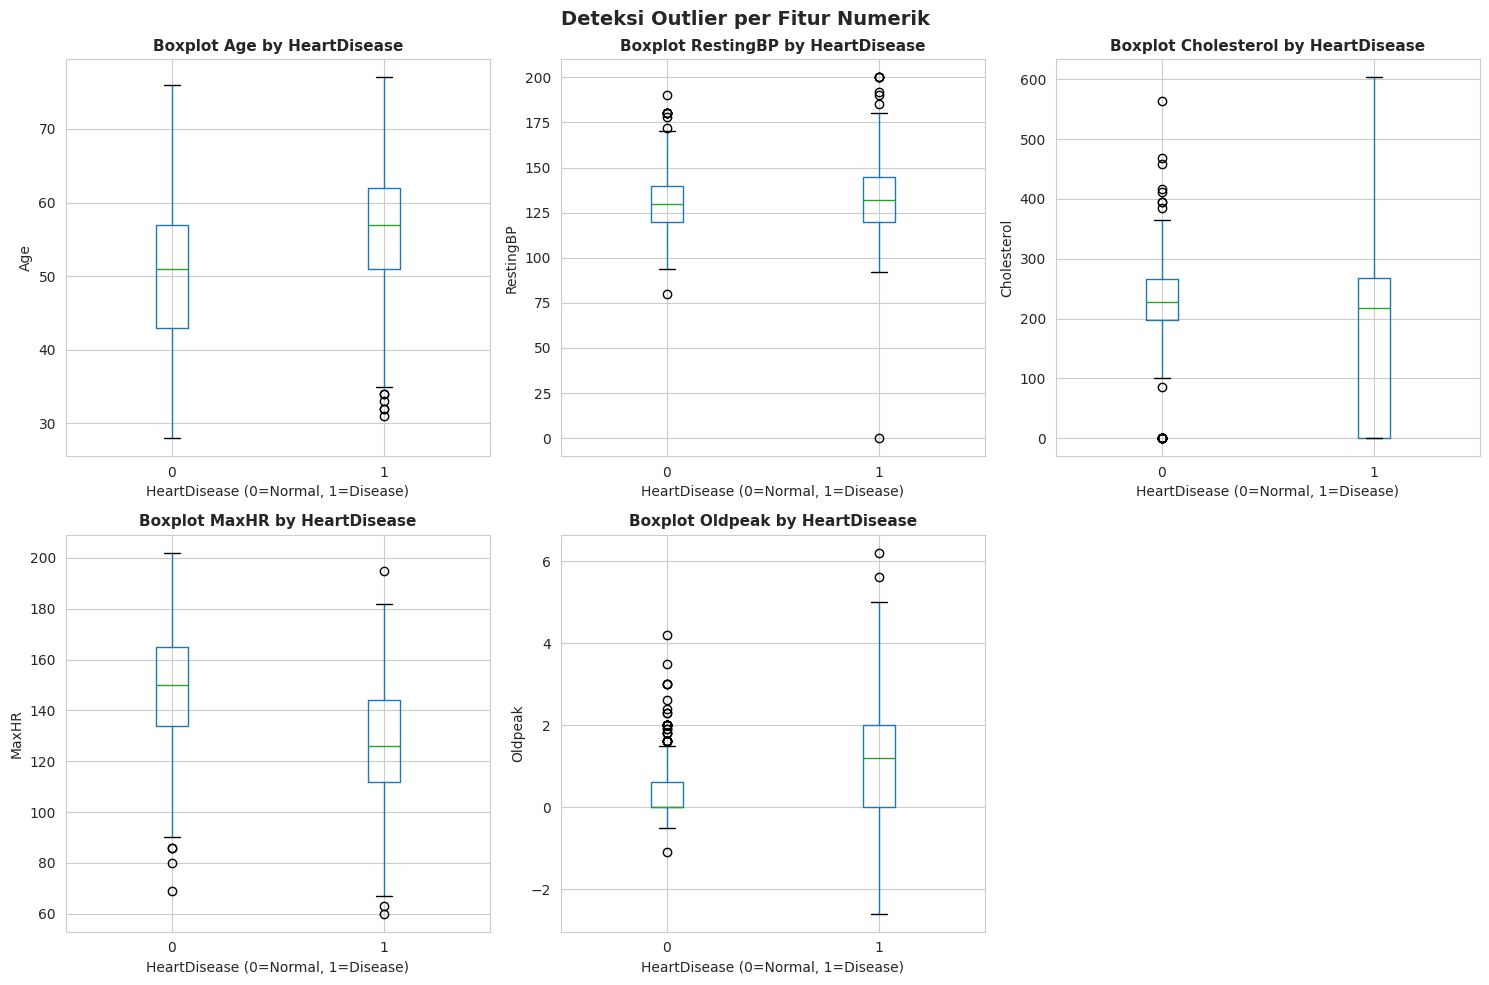

=== Deteksi Outlier (IQR Method) ===
Age            : 0 outlier(s) | Range valid: [27.50, 79.50]
RestingBP      : 28 outlier(s) | Range valid: [90.00, 170.00]
Cholesterol    : 183 outlier(s) | Range valid: [32.62, 407.62]
MaxHR          : 2 outlier(s) | Range valid: [66.00, 210.00]
Oldpeak        : 16 outlier(s) | Range valid: [-2.25, 3.75]


In [ ]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    df.boxplot(column=col, by='HeartDisease', ax=axes[i])
    axes[i].set_title(f'Boxplot {col} by HeartDisease', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('HeartDisease (0=Normal, 1=Disease)')
    axes[i].set_ylabel(col)

axes[5].set_visible(False)
plt.suptitle('Deteksi Outlier per Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()

# IQR method
print('=== Deteksi Outlier (IQR Method) ===')
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col:15s}: {len(outliers)} outlier(s) | Range valid: [{lower:.2f}, {upper:.2f}]')

### 4.6 Analisis Korelasi

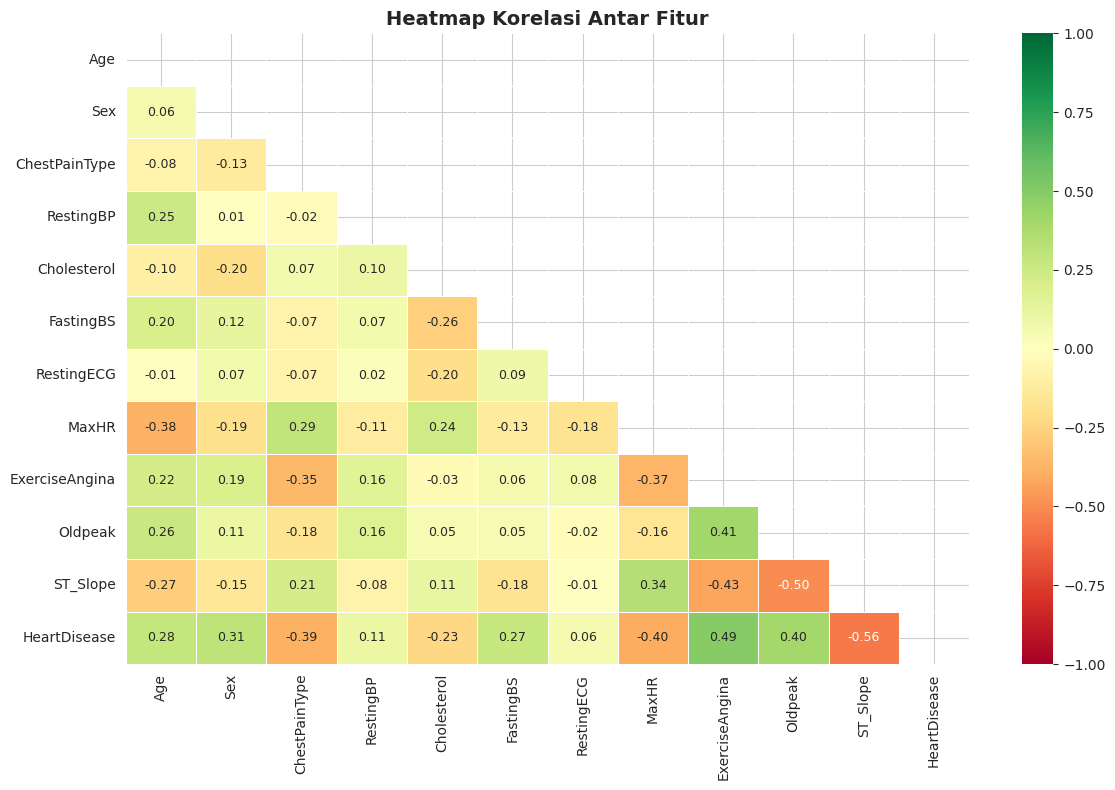


=== Korelasi dengan Target (HeartDisease) ===
ExerciseAngina    0.494282
Oldpeak           0.403951
Sex               0.305445
Age               0.282039
FastingBS         0.267291
RestingBP         0.107589
RestingECG        0.057384
Cholesterol      -0.232741
ChestPainType    -0.386828
MaxHR            -0.400421
ST_Slope         -0.558771
Name: HeartDisease, dtype: float64


In [ ]:
# Encode sementara untuk korelasi
df_corr = df.copy()
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
le = LabelEncoder()
for col in cat_cols:
    df_corr[col] = le.fit_transform(df_corr[col])

# Heatmap korelasi
plt.figure(figsize=(12, 8))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Korelasi terhadap target
print('\n=== Korelasi dengan Target (HeartDisease) ===')
target_corr = corr_matrix['HeartDisease'].drop('HeartDisease').sort_values(ascending=False)
print(target_corr)

### 4.7 Analisis Fitur Penting

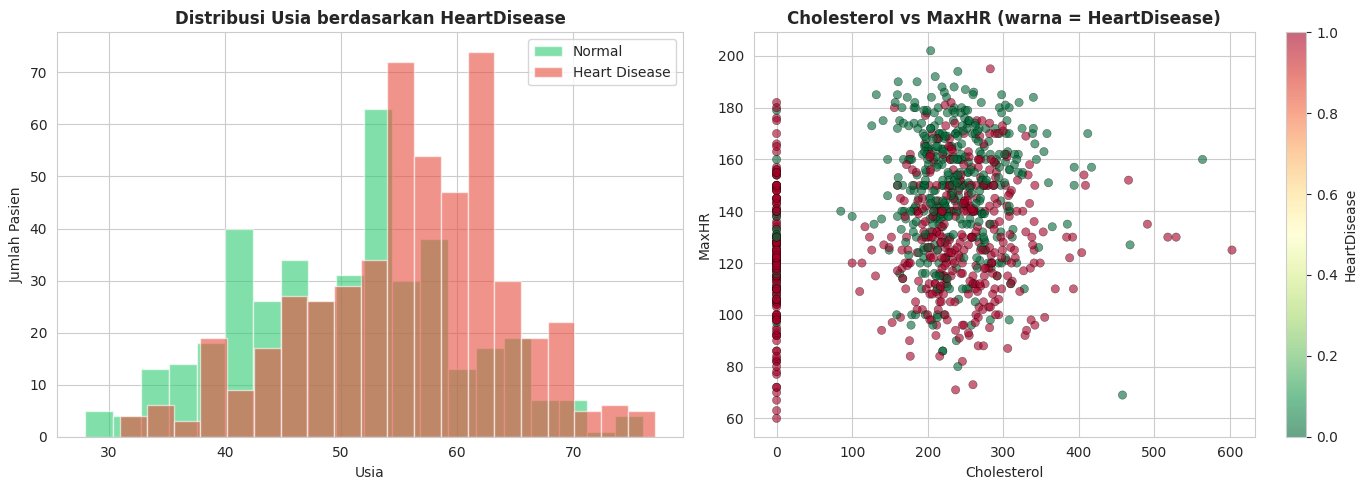

=== Ringkasan EDA ===
• Dataset memiliki 918 baris dan 12 kolom
• Tidak ada missing values
• Proporsi kelas: Normal=410 | Heart Disease=508
• Kolesterol=0 ditemukan pada 172 baris → perlu ditangani
• RestingBP=0 ditemukan pada 1 baris → perlu ditangani


In [ ]:
# Distribusi Age per kategori HeartDisease
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
df[df['HeartDisease']==0]['Age'].hist(ax=axes[0], alpha=0.6, label='Normal', bins=20, color='#2ecc71')
df[df['HeartDisease']==1]['Age'].hist(ax=axes[0], alpha=0.6, label='Heart Disease', bins=20, color='#e74c3c')
axes[0].set_title('Distribusi Usia berdasarkan HeartDisease', fontweight='bold')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Jumlah Pasien')
axes[0].legend()

# Cholesterol vs MaxHR scatter
scatter = axes[1].scatter(df['Cholesterol'], df['MaxHR'],
                          c=df['HeartDisease'], cmap='RdYlGn_r', alpha=0.6, edgecolors='k', linewidth=0.3)
axes[1].set_title('Cholesterol vs MaxHR (warna = HeartDisease)', fontweight='bold')
axes[1].set_xlabel('Cholesterol')
axes[1].set_ylabel('MaxHR')
plt.colorbar(scatter, ax=axes[1], label='HeartDisease')

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight ringkasan
print('=== Ringkasan EDA ===')
print(f'• Dataset memiliki {df.shape[0]} baris dan {df.shape[1]} kolom')
print(f'• Tidak ada missing values')
print(f'• Proporsi kelas: Normal={target_counts[0]} | Heart Disease={target_counts[1]}')
print(f'• Kolesterol=0 ditemukan pada {(df["Cholesterol"]==0).sum()} baris → perlu ditangani')
print(f'• RestingBP=0 ditemukan pada {(df["RestingBP"]==0).sum()} baris → perlu ditangani')

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### 5.1 Menangani Nilai Tidak Valid (Zero Values)

In [ ]:
df_processed = df.copy()

# Cholesterol = 0 secara medis tidak mungkin → ganti dengan median
chol_zero = (df_processed['Cholesterol'] == 0).sum()
print(f'Cholesterol = 0: {chol_zero} baris')
median_chol = df_processed[df_processed['Cholesterol'] != 0]['Cholesterol'].median()
df_processed['Cholesterol'] = df_processed['Cholesterol'].replace(0, median_chol)
print(f'Cholesterol = 0 diganti dengan median: {median_chol}')

# RestingBP = 0 → ganti dengan median
bp_zero = (df_processed['RestingBP'] == 0).sum()
print(f'\nRestingBP = 0: {bp_zero} baris')
if bp_zero > 0:
    median_bp = df_processed[df_processed['RestingBP'] != 0]['RestingBP'].median()
    df_processed['RestingBP'] = df_processed['RestingBP'].replace(0, median_bp)
    print(f'RestingBP = 0 diganti dengan median: {median_bp}')
else:
    print('Tidak ada nilai 0 pada RestingBP')

print('\n✅ Penanganan zero values selesai')

Cholesterol = 0: 172 baris
Cholesterol = 0 diganti dengan median: 237.0

RestingBP = 0: 1 baris
RestingBP = 0 diganti dengan median: 130.0

✅ Penanganan zero values selesai


### 5.2 Menangani Outlier (IQR Capping)

In [ ]:
# IQR Capping - menggunakan winsorization (bukan drop) agar data tidak berkurang banyak
def iqr_capping(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f'{col:15s}: {before} outlier(s) di-cap ke [{lower:.2f}, {upper:.2f}]')
    return df

print('=== IQR Capping untuk Fitur Numerik ===')
for col in numerical_cols:
    df_processed = iqr_capping(df_processed, col)

print(f'\n✅ Ukuran dataset setelah outlier handling: {df_processed.shape}')

=== IQR Capping untuk Fitur Numerik ===
Age            : 0 outlier(s) di-cap ke [27.50, 79.50]
RestingBP      : 27 outlier(s) di-cap ke [90.00, 170.00]
Cholesterol    : 41 outlier(s) di-cap ke [134.50, 346.50]
MaxHR          : 2 outlier(s) di-cap ke [66.00, 210.00]
Oldpeak        : 16 outlier(s) di-cap ke [-2.25, 3.75]

✅ Ukuran dataset setelah outlier handling: (918, 12)


### 5.3 Encoding Fitur Kategorikal

In [ ]:
# Encoding kategorikal
# Binary encoding manual
df_processed['Sex'] = df_processed['Sex'].map({'M': 1, 'F': 0})
df_processed['ExerciseAngina'] = df_processed['ExerciseAngina'].map({'Y': 1, 'N': 0})

print('Binary encoding:')
print('  Sex: M=1, F=0')
print('  ExerciseAngina: Y=1, N=0')

# One-Hot Encoding untuk fitur multi-kategori
ohe_cols = ['ChestPainType', 'RestingECG', 'ST_Slope']
df_processed = pd.get_dummies(df_processed, columns=ohe_cols, drop_first=False)

# Konversi boolean ke int
bool_cols = df_processed.select_dtypes(include='bool').columns
df_processed[bool_cols] = df_processed[bool_cols].astype(int)

print(f'\nOne-Hot Encoding untuk: {ohe_cols}')
print(f'Jumlah kolom setelah encoding: {df_processed.shape[1]}')
print(f'\nKolom baru: {list(df_processed.columns)}')

Binary encoding:
  Sex: M=1, F=0
  ExerciseAngina: Y=1, N=0

One-Hot Encoding untuk: ['ChestPainType', 'RestingECG', 'ST_Slope']
Jumlah kolom setelah encoding: 19

Kolom baru: ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


### 5.4 Normalisasi / Standarisasi Fitur

In [ ]:
# Pisahkan fitur dan target
X = df_processed.drop('HeartDisease', axis=1)
y = df_processed['HeartDisease']

# Split data train dan test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape}')
print(f'Test set : {X_test.shape}')

# StandardScaler hanya pada fitur numerik
scaler = StandardScaler()
num_cols_to_scale = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale] = scaler.transform(X_test[num_cols_to_scale])

print(f'\n✅ Standarisasi fitur numerik selesai')
print(f'Fitur yang di-scale: {num_cols_to_scale}')

Train set: (734, 18)
Test set : (184, 18)

✅ Standarisasi fitur numerik selesai
Fitur yang di-scale: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


### 5.5 Simpan Dataset yang Sudah Diproses

In [19]:
import os

# Gabungkan kembali untuk disimpan
train_data = X_train.copy()
train_data['HeartDisease'] = y_train.values

test_data = X_test.copy()
test_data['HeartDisease'] = y_test.values

os.makedirs('/content/heart_preprocessing', exist_ok=True)
train_data.to_csv('/content/heart_preprocessing/heart_train.csv', index=False)
test_data.to_csv('/content/heart_preprocessing/heart_test.csv', index=False)

print('✅ Dataset berhasil disimpan!')
print(f'  → heart_train.csv : {train_data.shape}')
print(f'  → heart_test.csv  : {test_data.shape}')
print(f'\nKolom akhir dataset: {list(train_data.columns)}')

✅ Dataset berhasil disimpan!
  → heart_train.csv : (734, 19)
  → heart_test.csv  : (184, 19)

Kolom akhir dataset: ['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up', 'HeartDisease']


## Ringkasan Preprocessing

| Tahap | Teknik | Keterangan |
|-------|--------|------------|
| Zero Values | Median Imputation | Cholesterol & RestingBP = 0 diganti median |
| Outlier | IQR Capping | Clip ke batas [Q1-1.5*IQR, Q3+1.5*IQR] |
| Encoding | Binary + One-Hot | Sex, ExerciseAngina → binary; ChestPainType, RestingECG, ST_Slope → OHE |
| Scaling | StandardScaler | Fitur numerik kontinu |
| Split | Train/Test 80:20 | Stratified split |

Dataset siap digunakan untuk pelatihan model! ✅